# Exploracion de la estructura de los datos.
Lo primero que hicimos fue analizar y explorar los datos y la estructura del archivo mediante diferentes funciones de la libreria pandas.  

**Funciones y atributos utilizados:**  
**1.-read_csv:** Lectura del archivo mediante pandas.  
**2.- Skiprows:** Realiza saltos de linea del archivo. Lo utilizamos ya que las primeras lineas del txt tienen informacion adicional al Data Frame. Los registros comienzan en la linea 20.  
**3.- Skipfooter:** Al contrario de skiprows, skipfooter hace los saltos empezando de la ultima linea del archivo. Lo utilizamos ya que el ultimo registro tiene guiones en vez de datos.  
**4.- Names:** Mediante una lista asigna los nombres de las columnas.  
**5.- Sep:** Se utiliza para definir un delimitador entre columnas. Lo utilizamos ya que pandas tomaba las columnas de names como columnas independientes y les asignaba nulos a todos los registros. r (raw) indica que debe tomar todos los caracteres como datos, \s+ es para los espacios en blanco.  
**6.-na_values** Sirve para indicar que una cadena es de tipo NaN. Le indicamos que los registros con el dato 'Nulo' contaran como nules. Esto solo para el analisis del archivo por lo que no modifica el dataframe.  
**7.- info():** Muestra un resumen del dataframe. Datos como el numero de registros, nombres de columna, tipos de dato, cantidad de nulos etc.  
**8.- shape:** Devuelve una tupla con las dimensiones del data frame (numero de filas y columnas).  
**9.- head():** Regresa las primeras filas del data frame.  
**10.- tail():** Muestra las ultimas filas del data frame.  
**11.- isnull().sum():** Hace la suma de todos los nulos por cada columna tambien muestra tipo de dato.  
**12.- nunique():** Devuelve la cantidad de registors unicos por cada columna.  


Lectura de archivos mediante pandas:

In [6]:
#Importacion de pandas y lectura del archivo.
import pandas as pd
df=pd.read_csv('./Dataset/BAdiraguato.txt',
skiprows=19, #saltamos las primeras 18 lineas del archivo
skipfooter=2,#saltamos las ultimas 2 lineas
names=['FECHA','PRECIP','EVAP','TMAX','TMIN'] , #Nombres de las columnas 
sep=r'\s+',#Separamos las columnas correctamente 
na_values='Nulo', #Asignamos como nulos los datos que contengan 'Nulo'
encoding='latin-1'
) 
df

C:\Users\santi\AppData\Local\Temp\ipykernel_12924\4227537579.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df=pd.read_csv('./Dataset/BAdiraguato.txt',


,FECHA,PRECIP,EVAP,TMAX,TMIN
0,01/01/1960,0.0,NaN,NaN,NaN
1,02/01/1960,0.0,NaN,NaN,NaN
2,03/01/1960,6.0,NaN,NaN,NaN
3,04/01/1960,30.0,NaN,NaN,NaN
4,05/01/1960,0.0,NaN,NaN,NaN
...,...,...,...,...,...
19177,25/04/2018,0.0,NaN,41.0,14.0
19178,26/04/2018,0.0,NaN,41.0,14.0
19179,27/04/2018,0.0,NaN,39.0,15.0
19180,28/04/2018,0.0,NaN,36.0,16.0


El Data Frame tiene un total 19574 registros, 5 columnas (FECHA, PRECIP, EVAP, TMAX Y TMIN todas de tipo String). 

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19182 entries, 0 to 19181
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FECHA   19182 non-null  str    
 1   PRECIP  19137 non-null  float64
 2   EVAP    9777 non-null   float64
 3   TMAX    18793 non-null  float64
 4   TMIN    18791 non-null  float64
dtypes: float64(4), str(1)
memory usage: 749.4 KB


In [8]:
df.shape

(19182, 5)

**Cada columna esta compuesta por:**  
**1.-Fecha:** fecha en dia, mes y año de la muestra.  
**2.-Precip:** precipitacion en milimietros de la muestra.  
**3.-Evap:** evaporacion en milimietros de la muestra.  
**4.-TMAX:** temperatura maxima en grados celsius de la muestra.  
**5.-TMIN** temperatura minima en grados celcius de la muestra.  


Las primeras 10 columnas muestran una precipitacion de 0, evaporacion en nulos, TMAX y TMIN muestran la temperatura maxima y minima en la fecha correspondiente.

In [9]:
df.head(10)

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,01/01/1960,0.0,NaN,NaN,NaN
1,02/01/1960,0.0,NaN,NaN,NaN
2,03/01/1960,6.0,NaN,NaN,NaN
3,04/01/1960,30.0,NaN,NaN,NaN
4,05/01/1960,0.0,NaN,NaN,NaN
5,06/01/1960,0.0,NaN,NaN,NaN
6,07/01/1960,0.0,NaN,NaN,NaN
7,08/01/1960,0.0,NaN,NaN,NaN
8,09/01/1960,0.0,NaN,NaN,NaN
9,10/01/1960,7.0,NaN,NaN,NaN


A diferencia de los primeros 10 registros, los ultimos 10 si cuentan con una precipitacion y evaporacion ademas de la temperatura maxima y minima.

In [10]:
df.tail(10)

,FECHA,PRECIP,EVAP,TMAX,TMIN
19172,20/04/2018,0.0,NaN,36.0,15.0
19173,21/04/2018,0.0,NaN,37.0,13.0
19174,22/04/2018,0.0,NaN,35.0,13.0
19175,23/04/2018,0.0,NaN,39.0,15.0
19176,24/04/2018,0.0,NaN,38.0,14.0
19177,25/04/2018,0.0,NaN,41.0,14.0
19178,26/04/2018,0.0,NaN,41.0,14.0
19179,27/04/2018,0.0,NaN,39.0,15.0
19180,28/04/2018,0.0,NaN,36.0,16.0
19181,29/04/2018,0.0,NaN,36.0,16.0


In [11]:
df.isnull().sum()

FECHA        0
PRECIP      45
EVAP      9405
TMAX       389
TMIN       391
dtype: int64

El data frame cuenta con 19574 registros. **Fecha tiene todos sus registros unicos** esto significa que no existen fechas repetidas.

In [12]:
df.nunique()

FECHA     19182
PRECIP      277
EVAP        144
TMAX         69
TMIN         66
dtype: int64

## Contabilizar numero de datos faltantes en fecha.  
Funciones y atributos utilizados:  
**1.-to_datetime():** Esta funcion convierte el tipo de dato a datetime.  
**2.-dayfirst:** Este atributo indica que el formato de la fecha es dia/mes/año. Lo utilizamos por que ese es el formato que tiene el archivo.  
**3.-dt.date:** Toma solamente la fecha del datetime dejando fuera la hora. Lo utilizamos por que no necesitamos la hora para contabilizar los dias faltantes.  
**4.-.loc:** Toma un registro determinado mediante fila-columna.  
**5.-date_range():** Crea un rango de fechas.   
**6.-difference():** Compara elementos entre dos series y guarda los elementos diferentes en otra serie.  


Lo primero que hicimos fue cambiar el tipo de dato de la columna fecha a date. Como date_time nos da el formato dia-mes-año hora:minuto:segundo utilizamos dt.date para solo obtener la fecha sin la hora.  
Despues inicializamos el rango de fechas que tiene el dataframe con date range y las fechas de inicio y final y una frecuendia en dias.  
A continuacion comparamos el rango completo con las fechas existentes en el dataframe y lo guardamos en fechas faltantes para despues imprimirlo.



In [13]:
def dias_faltantes(df):
    
    df['FECHA'] = pd.to_datetime(df['FECHA'],dayfirst=True)#Conversion de columna FECHA a datetime
    df['FECHA'] = df['FECHA'].dt.date #Tomamos solamente la fecha
    #Tomamos el rango de fechas del dataframe 1961-01-01 a 2018-07-31
    inicio=df.loc[0,'FECHA'] 
    final=df.loc[df.index[-1],'FECHA'] #.index[-1] para tomar el ultimo elemento de la columna
    rango_completo = pd.date_range(start=inicio, end=final, freq='D')
    fechas_faltantes = rango_completo.difference(df['FECHA'])
    print(f"Dias faltantes entre {inicio} y {final}: {len(fechas_faltantes)}")

#Ejecucion del metodo
dias_faltantes(df)

Dias faltantes entre 1960-01-01 y 2018-04-29: 2122


### ¿Cuántos datos nos faltan por cada año?
Antes de rellenar los espacios nulos, es muy importante saber en qué años la estación de Acatitán dejó de reportar datos. Esto nos ayuda a ver si la falta de información es algo de un solo año o si es constante.

In [14]:
def contar_nulos_por_anio(df_temp):
    """
    Función para contar cuántos datos faltan en cada columna, 
    separados por cada año del registro.
    """
    # Convertimos la columna de fecha a formato datetime, indicando que el día se muestra antes que el mes con el parámetro (dayfirst=True)
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)

    # Creamos la columna 'Año' extrayendo el año de la columna 'FECHA'
    df_temp['Año'] = df_temp['FECHA'].dt.year

    # Definimos las columnas numéricas que queremos analizar
    cols_clima = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']

    # Calculamos los nulos por año
    # isnull() crea True/False, al agrupar por 'Año' y usar .sum(), contamos cuántos True (nulos) hay por cada año
    nulos_por_anio = df[cols_clima].isnull().groupby(df['Año']).sum()

    # Mostramos el resultado de manera clara 
    print("--- Cantidad de datos nulos detectados por Año ---")
    display(nulos_por_anio)

    # Opcional: Ver el total general de nulos antes de proceder
    print("\nTotal de nulos en todo el registro:")
    print(df[cols_clima].isnull().sum())

    return df_temp

# Se manda a llamar la función
df = contar_nulos_por_anio(df)

--- Cantidad de datos nulos detectados por Año ---


,PRECIP,EVAP,TMAX,TMIN
Año,,,,
1960,0,330,330,330
1961,0,364,0,0
1962,0,365,0,0
1963,0,365,3,3
1964,1,366,0,0
1965,0,98,1,1
1966,0,3,0,1
1967,0,2,0,0
1968,0,5,0,0



Total de nulos en todo el registro:
PRECIP      45
EVAP      9405
TMAX       389
TMIN       391
dtype: int64


# Proceso de Transformación y Limpieza de Datos
En esta etapa, convertimos los datos crudos en un formato apto para el análisis estadístico. El proceso se ha dividido en funciones específicas que permiten un manejo controlado de la información.

### Librerías y Métodos Utilizados:
* **Pandas:** Utilizada para la estructuración y limpieza del DataFrame.
* **to_datetime (errors='coerce'):** Transforma la columna de fechas. El uso de `coerce` es fundamental para la **limpieza**, ya que convierte automáticamente cualquier texto inválido (como títulos o guiones) en valores `NaT` (Not a Time), evitando errores de ejecución.
* **dropna():** Elimina las filas que no contienen fechas válidas, asegurando que solo trabajemos con registros cronológicos reales.
* **to_numeric:** Convierte las columnas de medición (Precipitación, Evaporación, etc.) de texto a números decimales para permitir el cálculo de métricas.

In [15]:
def transformar_datos(df_temp):
    """
    Función modular para convertir tipos de datos y eliminar basura de texto.
    """
    # Convertimos la columna de fecha a formato datetime, indicando que el día se muestra antes que el mes con el parámetro (dayfirst=True)
    df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'], dayfirst=True)

    # Convertimos las columnas de datos a números 
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    df_temp[cols_num] = df_temp[cols_num].apply(pd.to_numeric) # Convertimos a datos númericos usando apply() para aplicar la función a cada columna
    
    return df_temp

# Llamada a la función
df = transformar_datos(df)
df.head()

,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
0,1960-01-01,0.0,NaN,NaN,NaN,1960
1,1960-01-02,0.0,NaN,NaN,NaN,1960
2,1960-01-03,6.0,NaN,NaN,NaN,1960
3,1960-01-04,30.0,NaN,NaN,NaN,1960
4,1960-01-05,0.0,NaN,NaN,NaN,1960


### Tratamiento de Valores Faltantes (Nulos)
Para garantizar la integridad del Análisis Exploratorio de Datos (EDA), es necesario tratar los valores nulos identificados previamente. Rellenamos los datos faltantes con la media

In [16]:
def aplicar_limpieza_nulos(df_temp):
    """
    Rellena los espacios vacíos con el promedio de la columna.
    """
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    
    # Rellenamos nulos con la media de cada columna 
    df_temp[cols_num] = df_temp[cols_num].fillna(df_temp[cols_num].mean())
    
    return df_temp

# Aplicamos la limpieza
df = aplicar_limpieza_nulos(df)
# Verificamos que ya no existan nulos
df.isnull().sum()

FECHA     0
PRECIP    0
EVAP      0
TMAX      0
TMIN      0
Año       0
dtype: int64

# Análisis Exploratorio de Datos final
En esta sección final, generamos las métricas estadísticas que solicita la rúbrica. El objetivo es identificar los valores máximos, mínimos, la media y la mediana de las variables climáticas registradas en la estación.

**Funciones Utilizadas:**
* **describe():** Para obtener un panorama estadístico global.
* **mean(), median(), max(), min():** Para cumplir con la identificación específica de métricas requeridas en el proyecto.

In [17]:
def ejecutar_eda(df_temp):
    """
    Calcula y muestra las estadísticas principales del dataset.
    """
    # Elegimos las columnas a utilizar para calcular los datos
    cols_num = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    
    print("--- RESUMEN ESTADÍSTICO ---")
    # Se muestra el resumen estadístico general de las columnas numéricas
    display(df_temp[cols_num].describe())
    
    print("\n--- MÉTRICAS ESPECÍFICAS SOLICITADAS ---")
    # Creamos un DataFrame para mostrar las métricas específicas de media, mediana, máximo y mínimo
    stats_resumen = pd.DataFrame({
        'Media (Promedio)': df_temp[cols_num].mean(), # Calculamos la media de cada columna numérica
        'Mediana': df_temp[cols_num].median(), # Calculamos la mediana de cada columna numérica
        'Valor máximo': df_temp[cols_num].max(), # Calculamos el valor máximo de cada columna numérica
        'Valor mínimo': df_temp[cols_num].min() # Calculamos el valor mínimo de cada columna numérica
    })
    display(stats_resumen)

# Ejecutamos el análisis final
ejecutar_eda(df)

--- RESUMEN ESTADÍSTICO ---


,PRECIP,EVAP,TMAX,TMIN
count,19182.000000,19182.000000,19182.000000,19182.000000
mean,2.577144,5.097126,33.647182,15.501107
std,10.265505,1.903083,4.079948,6.724151
min,0.000000,0.000000,13.500000,-5.000000
25%,0.000000,4.400000,31.500000,10.000000
50%,0.000000,5.097126,34.000000,15.000000
75%,0.000000,5.097126,36.000000,22.000000
max,335.000000,16.000000,47.000000,30.000000



--- MÉTRICAS ESPECÍFICAS SOLICITADAS ---


,Media (Promedio),Mediana,Valor máximo,Valor mínimo
PRECIP,2.577144,0.000000,335.0,0.0
EVAP,5.097126,5.097126,16.0,0.0
TMAX,33.647182,34.000000,47.0,13.5
TMIN,15.501107,15.000000,30.0,-5.0


# Nombrar el archivo leyendolo.
Se busca crear un nuevo archivo apartir del archivo colocando clave, nombre y fecha como en el siguiente ejemplo:  
CVE  _ NOMBRE _  FECHA   
25001_GVE01_14052025   

Funciones utilizadas:  
**1.-open():**Funcion de python que sirve para abrir archivos.  
**2.-read():**Crea una lista con las lineas del archivo.
**3.-.split():**Divide un string en una lista de substrings
**4.-strip():** Remueve caracteres especiales.
**5.-replace():** Remplaza los caracteres de un string por otro.
**6.-to_csv():** Crea un nuevo archivo csv apartir de un dataframe.

Primeramente abrimos el archivo, creamos una lista con las lineas del archivo y despues creamos una variable para clave, nombre y fecha.
Estas variables las construimos primeramente diviendo el numero de linea correspondiente separada por dos puntos con split(). Despues con strip() agarramos el dato que nombrara al archivo sin caracteres especiales. Ejemplo:

linea antes del procesamiento:  
ESTACION  : 25001  
linea despues del procesamiento:  
25001

Para el caso de la fecha necesitamos remover los / para que cumpla con el formato mencionado anteriormente. Finalmente creamos un archivo csv nuevo con los datos del dataframe.  
Finalmente creamos el archivo csv con el nombre del archivo nuevo y el dataframe con los datos limpios.

In [18]:
def crearArchivo (nombre_archivo,df):
    archivo =open(nombre_archivo) 
    lineas = archivo.readlines() #lista de lineas 
    clave = lineas[4].split(':')[1].strip() # Dividimos la linea 5 del archivo separando
    nombre = lineas[5].split(':')[1].strip() 
    fecha = lineas[15].split(':')[1].strip().replace('/','')#replace para quitar los / en la fecha y cumplir con el formato
    nuevo_archivo = 'Dataset/' + clave + '_' + nombre + '_' + fecha + '.csv'
    df.to_csv(nuevo_archivo,index=False)

crearArchivo('Dataset/BAdiraguato.txt',df)# Nombre del archivo y dataframe del que se creara el nuevo archivo 

# Visualización de los resultados
Para terminar con el análisis exploratorio (EDA), vamos a crear un par de gráficas sencillas que nos ayuden a ver cómo se comportan las temperaturas y la lluvia en Acatitán. 

**Gráficas que vamos a generar:**
1. **Histogramas:** Para ver qué tan seguido se repiten ciertas temperaturas.
2. **Gráfica de líneas:** Para observar cómo cambia la temperatura a lo largo del tiempo.

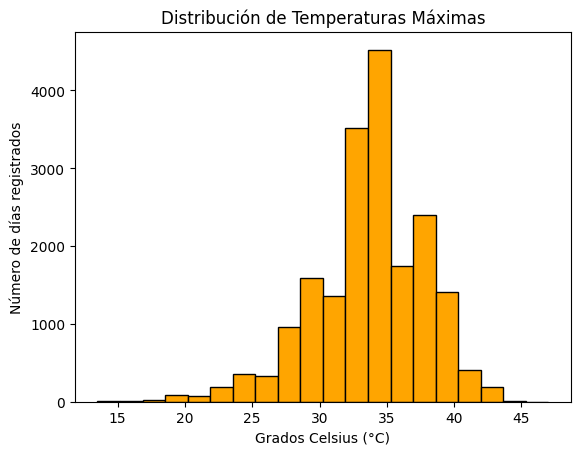

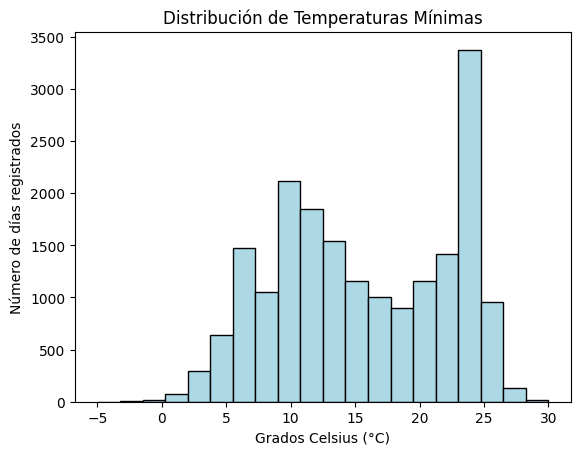

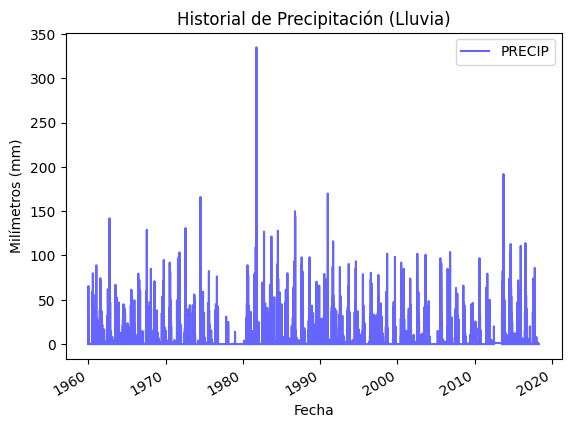

In [19]:
import matplotlib.pyplot as plt

def graficar_datos(df_temp):
    """
    Crea gráficas básicas para entender mejor visualmente los resultados de los datos del clima.
    """
    # Histograma de Temperaturas Máximas
    # Esta gráfica nos dice en qué rango de grados máximos se mantiene la temperatura en la estación
    # bins nos sirve para decidir cuántas barras queremos ver
    # edgecolor nos ayuda a resaltar el contorno de cada barra del histograma para una mejor visualización
    df_temp['TMAX'].plot(kind='hist', bins= 20,color='orange', edgecolor='black') 
    plt.title('Distribución de Temperaturas Máximas')
    plt.xlabel('Grados Celsius (°C)')
    plt.ylabel('Número de días registrados')
    plt.show()

    # Histograma de Temperaturas Mínimas
    # Esta gráfica nos dice en qué rango de grados mínimos se mantiene la temperatura en la estación
    df_temp['TMIN'].plot(kind='hist', bins=20, color='lightblue', edgecolor='black') 
    plt.title('Distribución de Temperaturas Mínimas')
    plt.xlabel('Grados Celsius (°C)')
    plt.ylabel('Número de días registrados')
    plt.show()

    # Gráfica de Lluvia (Precipitación)
    # Usamos una gráfica de líneas para ver la probabilidad de lluvia en base a la fecha
    df_temp.plot(x='FECHA', y='PRECIP', color='blue', alpha=0.6) # El parametro alpha sirve para dar transparencia a la gráfica
    plt.title('Historial de Precipitación (Lluvia)')
    plt.xlabel('Fecha')
    plt.ylabel('Milímetros (mm)')
    plt.show()

# Ejecutamos las gráficas 
graficar_datos(df)

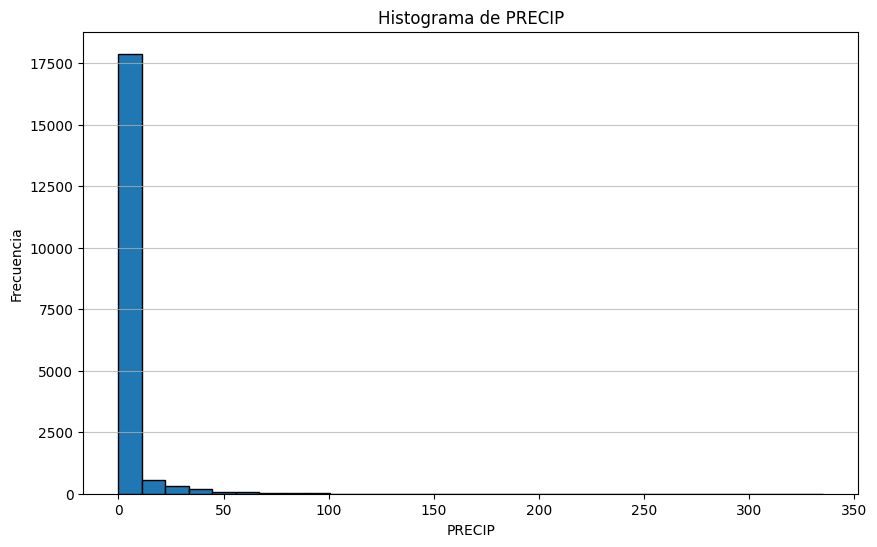

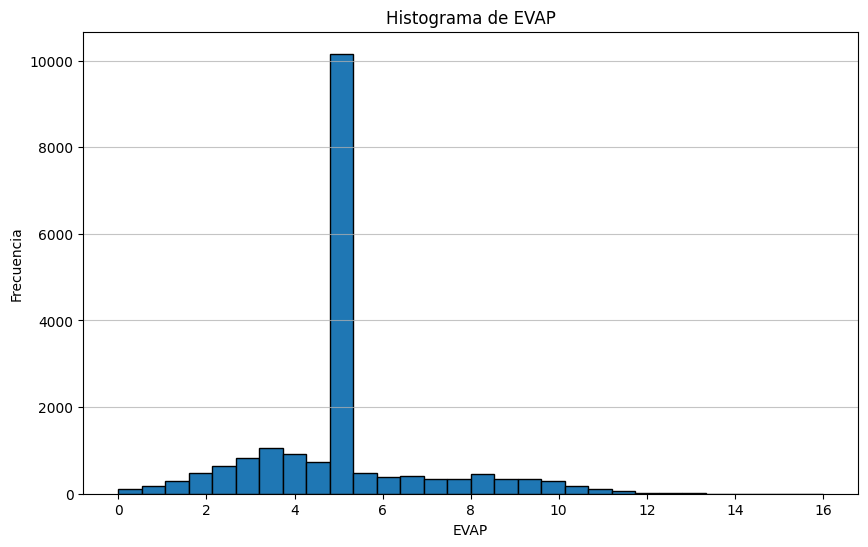

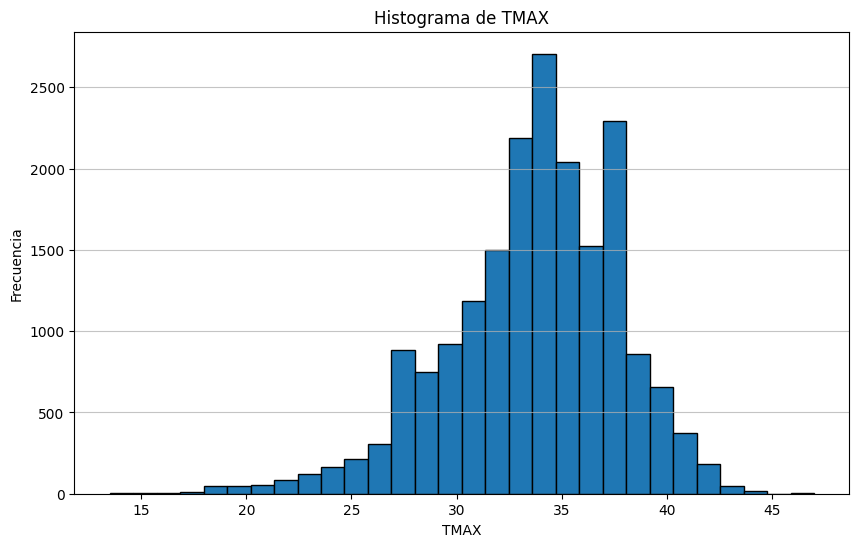

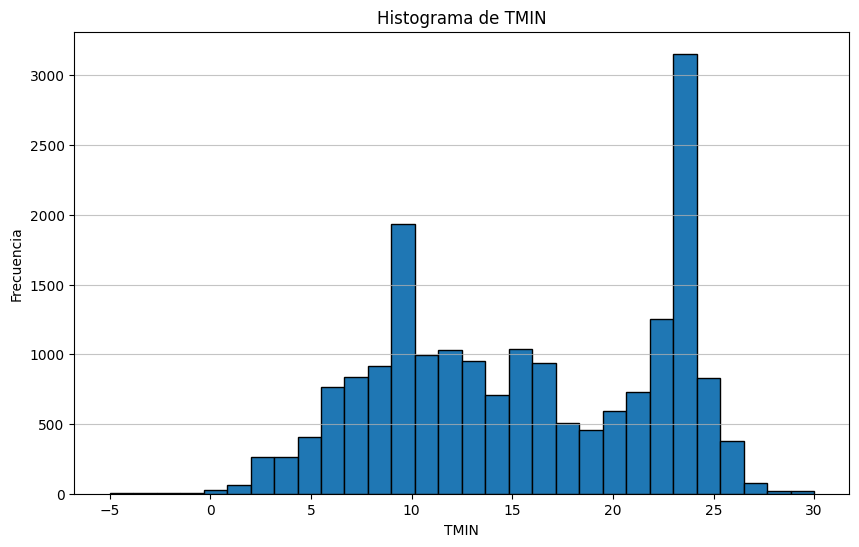

,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
count,19182,19182.000000,19182.000000,19182.000000,19182.000000,19182.000000
mean,1988-11-15 17:09:30,2.577144,5.097126,33.647182,15.501107,1988.376707
min,1960-01-01 00:00:00,0.000000,0.000000,13.500000,-5.000000,1960.000000
25%,1973-03-25 06:00:00,0.000000,4.400000,31.500000,10.000000,1973.000000
50%,1989-06-09 12:00:00,0.000000,5.097126,34.000000,15.000000,1989.000000
75%,2002-09-20 18:00:00,0.000000,5.097126,36.000000,22.000000,2002.000000
max,2018-04-29 00:00:00,335.000000,16.000000,47.000000,30.000000,2018.000000
std,NaN,10.265505,1.903083,4.079948,6.724151,16.906644


In [20]:
import matplotlib.pyplot as plt

def graficar_datos2(df_temp):
    # Histograma de cada una de las columnas del dataframe BAdiraguato.txt
    for column in ["PRECIP", "EVAP", "TMAX", "TMIN", ]:
        plt.figure(figsize=(10, 6))
        plt.hist(df_temp[column], bins=30, edgecolor='black')
        plt.title(f'Histograma de {column}')
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
        plt.grid(axis='y', alpha=0.75)
        plt.show()

graficar_datos2(df)
df.describe()

In [21]:
# Filtrado por el año 1985

df_1985 = df[df['FECHA'].dt.year == 1985]
df_1985.head(15)


,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
7970,1985-01-01,0.0,2.1,28.0,9.0,1985
7971,1985-01-02,0.0,1.5,27.0,8.0,1985
7972,1985-01-03,0.0,3.6,27.0,6.0,1985
7973,1985-01-04,0.0,2.6,28.5,4.0,1985
7974,1985-01-05,0.0,1.8,29.0,2.5,1985
7975,1985-01-06,0.0,2.8,30.0,3.0,1985
7976,1985-01-07,0.0,2.2,29.0,4.0,1985
7977,1985-01-08,0.0,2.3,29.0,6.5,1985
7978,1985-01-09,0.0,2.1,28.0,9.5,1985
7979,1985-01-10,0.0,2.1,28.0,8.0,1985


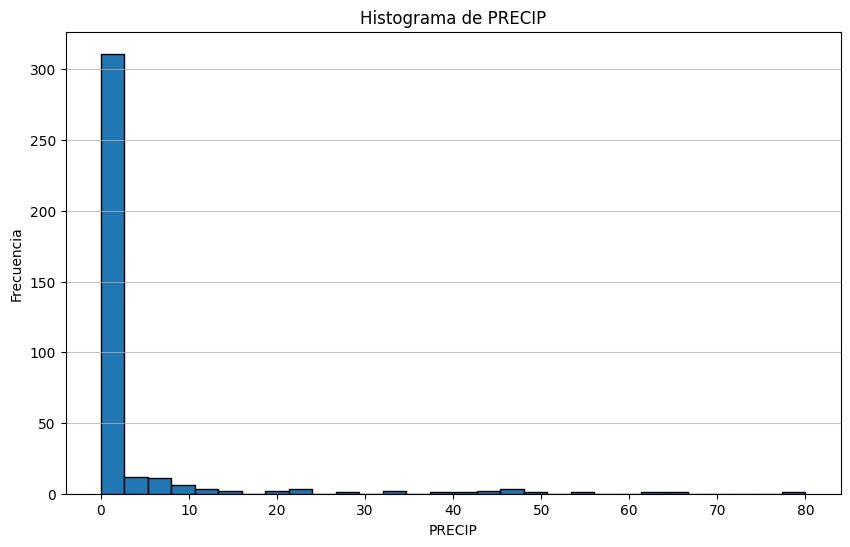

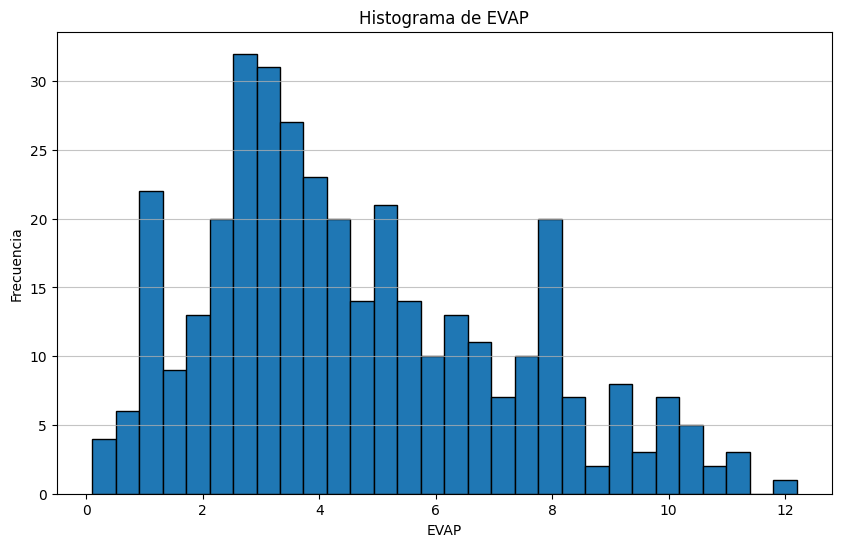

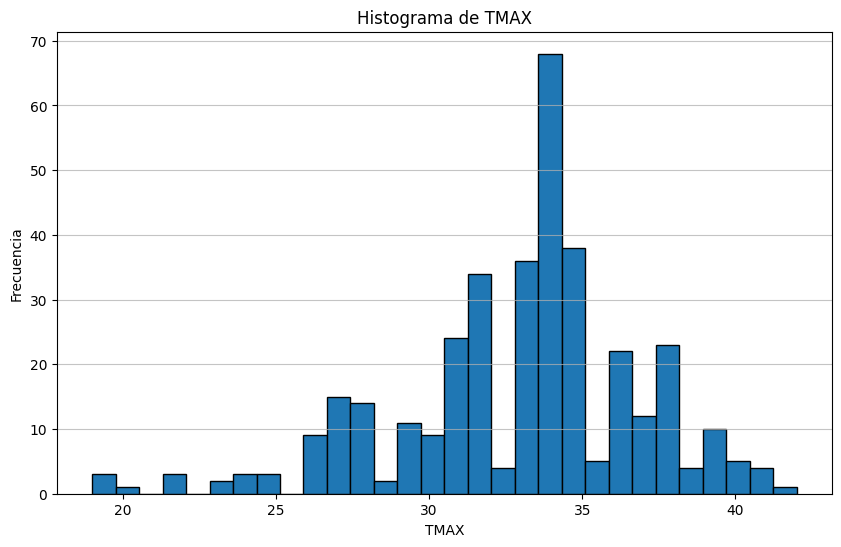

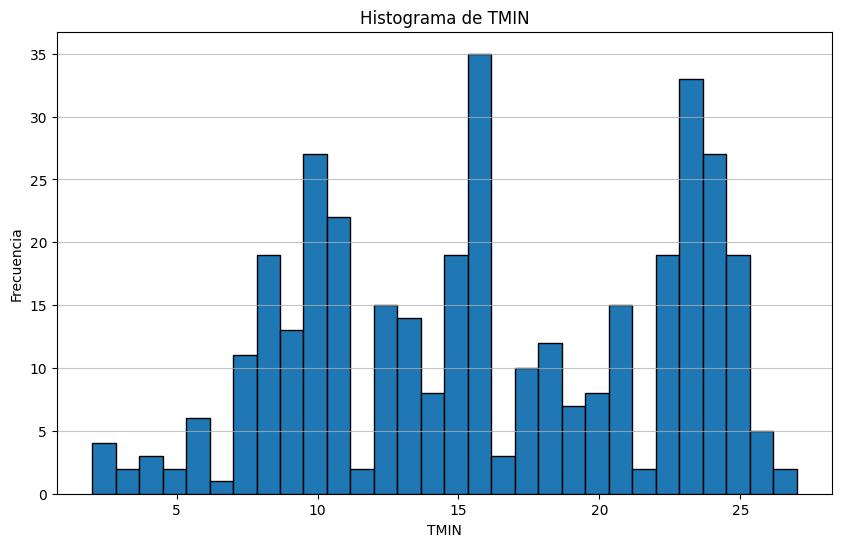

,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
count,19182,19182.000000,19182.000000,19182.000000,19182.000000,19182.000000
mean,1988-11-15 17:09:30,2.577144,5.097126,33.647182,15.501107,1988.376707
min,1960-01-01 00:00:00,0.000000,0.000000,13.500000,-5.000000,1960.000000
25%,1973-03-25 06:00:00,0.000000,4.400000,31.500000,10.000000,1973.000000
50%,1989-06-09 12:00:00,0.000000,5.097126,34.000000,15.000000,1989.000000
75%,2002-09-20 18:00:00,0.000000,5.097126,36.000000,22.000000,2002.000000
max,2018-04-29 00:00:00,335.000000,16.000000,47.000000,30.000000,2018.000000
std,NaN,10.265505,1.903083,4.079948,6.724151,16.906644


In [22]:
# Histograma por el año 1985

def graficar_datos2(df_temp):
    # Histograma de cada una de las columnas del dataframe BAdiraguato.txt
    for column in ["PRECIP", "EVAP", "TMAX", "TMIN", ]:
        plt.figure(figsize=(10, 6))
        plt.hist(df_1985[column], bins=30, edgecolor='black')
        plt.title(f'Histograma de {column}')
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
        plt.grid(axis='y', alpha=0.75)
        plt.show()

graficar_datos2(df)
df.describe()

In [24]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import seaborn as sns

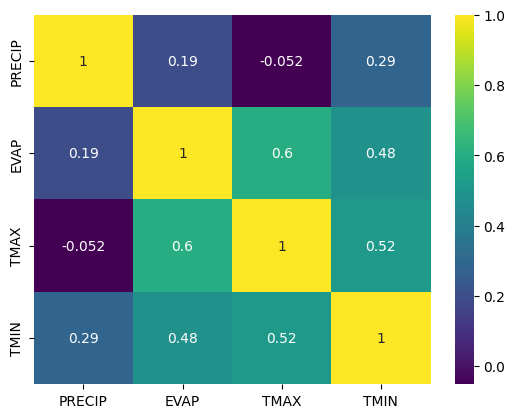

In [35]:
# Mapa de calor

columnas = ["PRECIP", "EVAP", "TMAX", "TMIN"]

dfx = df_1985[columnas].corr()

sns.heatmap(dfx, annot= True, cmap = 'viridis')
plt.show()

# Esto nos dice que entre mayor temperatura aumenta la evaporación, debido a que se tiene una correlación mayor a 0.5


In [27]:
# Filtrado decada de los 90s

df_decada = df[df['FECHA'].dt.year.between(1990, 1999)]
df_decada.head(15)


,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
9796,1990-01-01,0.0,2.7,25.0,8.0,1990
9797,1990-01-02,0.0,1.8,27.0,8.0,1990
9798,1990-01-03,0.0,1.8,28.0,7.0,1990
9799,1990-01-04,0.0,2.9,26.0,10.0,1990
9800,1990-01-05,0.0,0.5,15.5,11.0,1990
9801,1990-01-06,0.0,2.0,21.5,3.0,1990
9802,1990-01-07,0.0,2.4,26.0,0.0,1990
9803,1990-01-08,0.0,1.9,30.0,1.0,1990
9804,1990-01-09,0.0,4.0,32.0,1.0,1990
9805,1990-01-10,0.0,2.9,35.0,2.0,1990


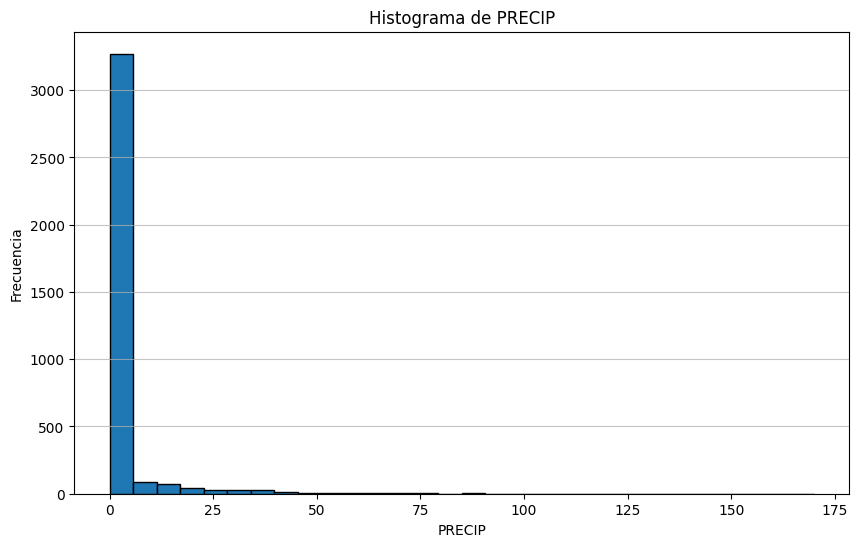

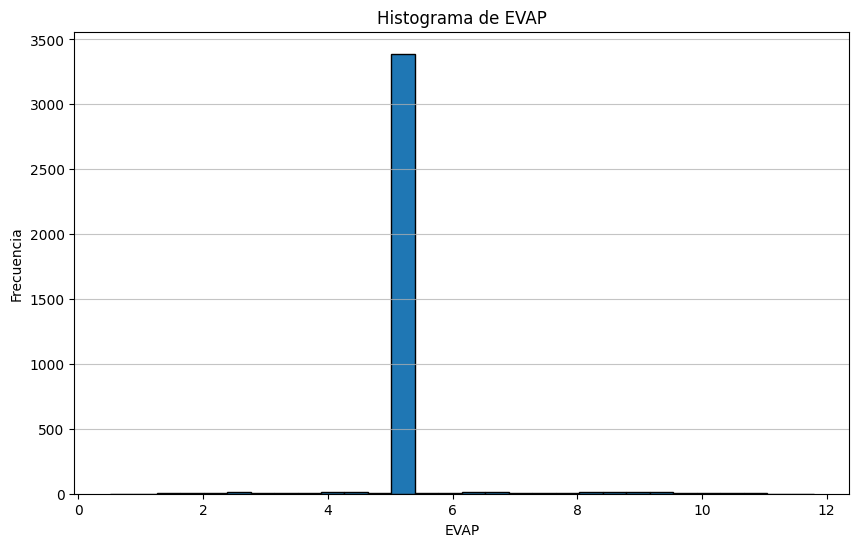

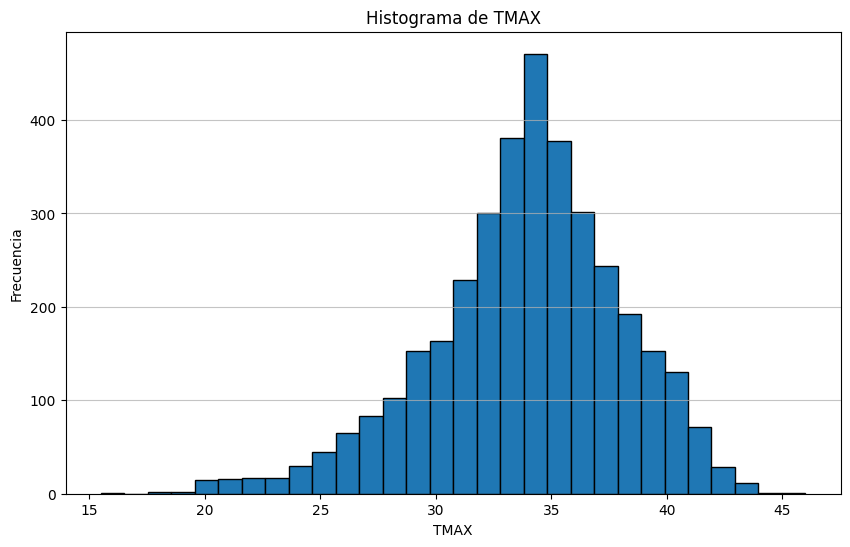

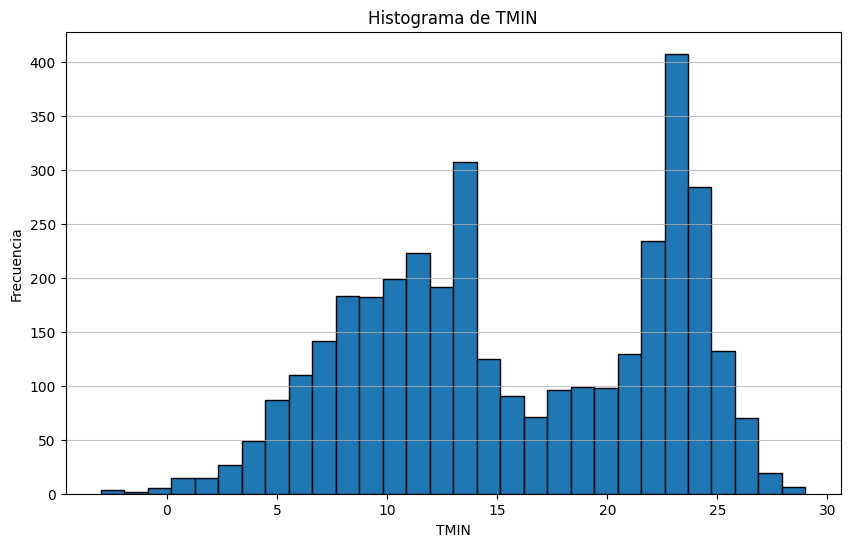

,FECHA,PRECIP,EVAP,TMAX,TMIN,Año
count,19182,19182.000000,19182.000000,19182.000000,19182.000000,19182.000000
mean,1988-11-15 17:09:30,2.577144,5.097126,33.647182,15.501107,1988.376707
min,1960-01-01 00:00:00,0.000000,0.000000,13.500000,-5.000000,1960.000000
25%,1973-03-25 06:00:00,0.000000,4.400000,31.500000,10.000000,1973.000000
50%,1989-06-09 12:00:00,0.000000,5.097126,34.000000,15.000000,1989.000000
75%,2002-09-20 18:00:00,0.000000,5.097126,36.000000,22.000000,2002.000000
max,2018-04-29 00:00:00,335.000000,16.000000,47.000000,30.000000,2018.000000
std,NaN,10.265505,1.903083,4.079948,6.724151,16.906644


In [28]:
def graficar_datos_decada(df_temp):
    # Histograma de cada una de las columnas del dataframe BAdiraguato.txt por decada de los 90s
    for column in ["PRECIP", "EVAP", "TMAX", "TMIN", ]:
        plt.figure(figsize=(10, 6))
        plt.hist(df_decada[column], bins=30, edgecolor='black')
        plt.title(f'Histograma de {column}')
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
        plt.grid(axis='y', alpha=0.75)
        plt.show()

graficar_datos_decada(df)
df.describe()

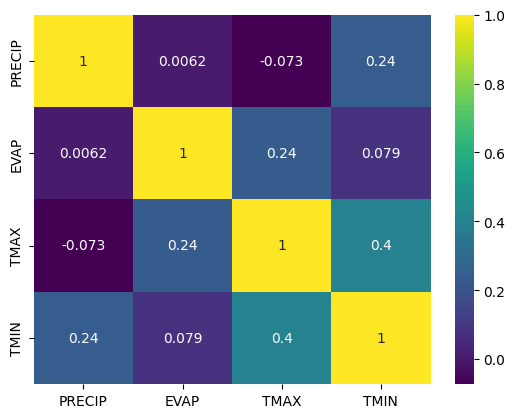

In [36]:
# Mapa de calor por decada

columnas = ["PRECIP", "EVAP", "TMAX", "TMIN"]

dfx = df_decada[columnas].corr()

sns.heatmap(dfx, annot= True, cmap = 'viridis')
plt.show()